<a href="https://colab.research.google.com/github/BaeJinYeong01/-/blob/main/line_balancing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 문제
실습 1. 라인밸런싱 (심화)

제품 1과 2를 생산하는 공정이 아래와 같이 배치되어 있다. 생산팀장의 입장에서 공정효율성을 높이기 위해 어느 공정을 개선해야 할지 라인밸런싱 관점에서 근거를 제시해 보시오.

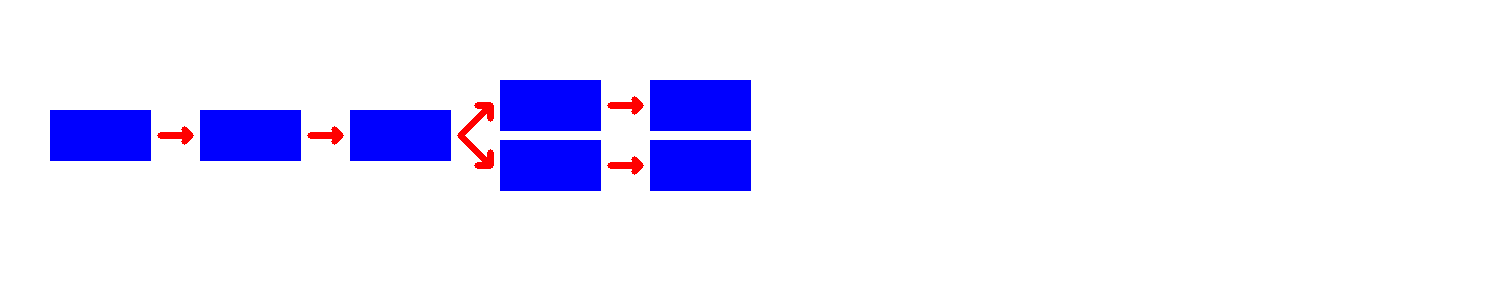

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Necessary import if we are working in Google Colab. Otherwise,
# if will use cv2.imshow(), this import is not required.
from google.colab.patches import cv2_imshow

img = np.zeros((300, 1500, 3), dtype="uint8")
img[:] = (255,255,255)
cv2.rectangle(img, (50,110), (150,160), (255,0,0), (-1))
cv2.arrowedLine(img, (160,135), (190,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (200,110), (300,160), (255,0,0), (-1))
cv2.arrowedLine(img, (310,135), (340,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (350,110), (450,160), (255,0,0), (-1))

cv2.arrowedLine(img, (460,135), (490,105), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (500,80), (600,130), (255,0,0), (-1))
cv2.arrowedLine(img, (610,105), (640,105), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (650,80), (750,130), (255,0,0), (-1))


cv2.arrowedLine(img, (460,135), (490,165), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (500,140), (600,190), (255,0,0), (-1))
cv2.arrowedLine(img, (610,165), (640,165), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (650,140), (750,190), (255,0,0), (-1))


cv2_imshow(img)

# 접근 방법

각 공정을 동시에 시작할 수 있기 때문에 공정별로 걸리는 시간을 비슷하게 만들면 공정효율성을 높일 수 있습니다. 따라서 각 공정별 평균 소요시간을 구하고 독보적으로 시간이 오래 걸리는 병목 공정이 있다면 병목 공정의 시간을 줄이거나 합칠 수 있는 다른 공정들을 합쳐서 걸리는 시간이 비슷하게 만드는 방식으로 공정효율성을 높일 수 있습니다. 기본에서는 공정을 합쳐서 공정효율성을 높였다면, 심화에서는 병목 공정을 개선하는 방법을 통해서 효율성을 높이는 방법을 제시해 보도록 하겠습니다.

1. 공정별 평균 소요시간을 구합니다.

2. 제품 하나를 완성하는데 걸리는 평균 소요시간을 구합니다.

3. 공정별 평균 소요시간을 비교해서 제품별 병목공정을 구합니다.

4. 공정 효율성을 구합니다.

5. 각 공정의 생산능력이 2배로 증대되었을 때 개선된 공정 효율성을 구해보고 공정 효율성이 가장 많이 증대되는 공정을 제시합니다.

# 1. 공정별 평균 소요시간을 구합니다.


데이터를 먼저 읽어들입니다.

In [ ]:
from google.colab import files
upldaded = files.upload()
## Data를 Colab으로 Upload 해 보시기 바랍니다.


Saving exercise_1_advanced.xlsx to exercise_1_advanced.xlsx


In [ ]:
import pandas as pd
import numpy as np
import io
df = pd.read_excel('/content/exercise_1_advanced.xlsx')
df.head()


,A Process,B Process,C Process,D1 Process,E1 Process,D2 Process,E2 Process
0,3.073477,2.026201,4.921203,3.300989,3.757260,1.931495,4.922032
1,2.898215,1.918090,4.724632,2.853953,3.745583,1.910709,5.062760
2,3.081167,1.993536,5.339799,3.018873,4.100176,2.124015,5.099334
3,3.012130,1.979814,5.354191,3.019600,3.851164,1.984330,4.883973
4,3.010588,2.018474,4.969430,2.836426,3.993447,1.964788,5.047786


In [ ]:
tips=pd.read_excel("/content/exercise_1_advanced.xlsx")
tips.head()

,A Process,B Process,C Process,D1 Process,E1 Process,D2 Process,E2 Process
0,3.073477,2.026201,4.921203,3.300989,3.757260,1.931495,4.922032
1,2.898215,1.918090,4.724632,2.853953,3.745583,1.910709,5.062760
2,3.081167,1.993536,5.339799,3.018873,4.100176,2.124015,5.099334
3,3.012130,1.979814,5.354191,3.019600,3.851164,1.984330,4.883973
4,3.010588,2.018474,4.969430,2.836426,3.993447,1.964788,5.047786


In [ ]:
df_ave = df.mean()
print(df_ave)



A Process     2.999490
B Process     1.999957
C Process     5.000553
D1 Process    2.998877
E1 Process    4.000854
D2 Process    2.002513
E2 Process    4.997950
dtype: float64


In [ ]:
print(df.var())

A Process     0.010109
B Process     0.003585
C Process     0.022553
D1 Process    0.014555
E1 Process    0.039910
D2 Process    0.014478
E2 Process    0.014005
dtype: float64


# 2. 제품 하나를 완성하는데 걸리는 평균 소요시간을 구합니다.

모든 공정별 평균 소요시간을 합해서 제품 하나를 완성하는데 걸리는 평균 소요시간을 구합니다.
제품 1을 만들기 위해서는 A, B, C, D1, 그리고 E1의 공정을 거쳐야 하기 때문에 A, B, C, D1, 그리고 E1 공정의 평균 소요시간을 합해야 합니다. 제품 2를 만들기 위해서는 A, B, C, D2, 그리고 E2의 공정을 거쳐야 하기 때문에 A, B, C, D2, 그리고 E2 공정의 평균 소요시간을 합해야 합니다.

In [ ]:
print('product 1 : ',df_ave[0:5].sum(),'\n')
product2_time = (
    df_ave['A Process'] +
    df_ave['B Process'] +
    df_ave['C Process'] +
    df_ave['D2 Process'] +
    df_ave['E2 Process']
)

print("product 2 :", product2_time)

## 제품2를 완성하는데 걸리는 평규 소요 시간을 구해보시오. (D1와 E1 대신에 D2와 E2를 대입하면 됨)



product 1 :  16.999730609966708 

product 2 : 17.000462227841574


# 3. 공정별 평균 소요시간을 비교해서 병목공정을 구합니다.

앞서 구한 공정별 평균 소요시간을 비교해서 가장 오래 걸리는 공정을 구합니다.
제품 1을 위해서는 A, B, C, D1, E1이 필요하고, 제품 2를 위해서는 A, B, C, D2, E2가 필요합니다. 제품만 보면 각 공정을 한번만 거치는 거지만, 공장 전체적으로 보면 제품 1과 제품2를 동시에 만들어야 하기 때문에 각 제품을 실제로 만들기 위해서는 공정 A, B, C의 경우에는 평균 소요시간의 2배가 걸리게 됩니다. 따라서 A, B, C 의 경우에는 2를 곱하고, 나머지 D1과 D2, 그리고 E1과 E2에 대해서는 평균 소요시간을 그대로 사용해서 최종적으로 병목 공정을 구하게 됩니다. 여기서 제품 1과 제품2를 만드는 수는 1:1 이라고 가정하도록 하겠습니다.

In [ ]:
p1 = [df_ave['A Process']*2, df_ave['B Process']*2, df_ave['C Process']*2, df_ave['D1 Process'], df_ave['E1 Process']]
print(p1)
p2 = {
    'A Process': df_ave['A Process']*2,
    'B Process': df_ave['B Process']*2,
    'C Process': df_ave['C Process']*2,
    'D2 Process': df_ave['D2 Process'],
    'E2 Process': df_ave['E2 Process']
}

bottleneck_p2 = max(p2, key=p2.get)

print("제품2 병목공정 :", bottleneck_p2)
print("병목 시간 :", p2[bottleneck_p2])
## 제품 2의 병목 공정을 구해보시오. (D1과 E1 대신에 D2와 E2를 대입하면 됨)



[np.float64(5.998979973526962), np.float64(3.9999134806116623), np.float64(10.001105683856373), np.float64(2.9988768318802608), np.float64(4.000854209088949)]
제품2 병목공정 : C Process
병목 시간 : 10.001105683856373


# 4. 공정효율성을 구합니다.

공정별 효율성을 구하는 공식은 공정별 가동시간을 합산해서 병목공정의 평균 공정 소요시간에 공정의 갯수를 곱한 값으로 나누는 것이다. 즉, 총 가용 시간 중에서 유휴시간을 제외한 부분을 고려한다고 볼 수 있다. 위에서 만든 p1과 p2를 이용해서 공정효율성을 구합니다.

In [ ]:
print(sum(p1)/(max(p1)*5))
p2_list = [
    df_ave['A Process']*2,
    df_ave['B Process']*2,
    df_ave['C Process']*2,
    df_ave['D2 Process'],
    df_ave['E2 Process']
]

efficiency_p2 = sum(p2_list) / (max(p2_list) * 5)

print("제품2 공정효율 :", efficiency_p2)
## 제품 2의 공정효율성을 구해보시오.


0.5399349038486163
제품2 공정효율 : 0.5399495345884164


# 5. 각 공정의 생산능력이 2배로 증대되었을 때 개선된 공정 효율성을 구해보고 공정 효율성이 가장 많이 증대되는 공정을 제시합니다. 현재 가장 오랜 시간이 소요되는 공정을 개선하는 것이 가장 효율적이기 때문에 시간이 가장 오래 걸리는 것을 개선합니다.

  

생산능력이 2배로 증대가 된다면 평균 소요 시간이 반으로 줄어든다는 것을 의미하기 때문에 병목공정의 생산능력이 증대가 되는 것이 가장 좋습니다. 병목 공정의 생산능력이 2배가 된 경우 해당 공정에 2를 곱해서 만들었던 p1과 p2에서 c process만 그대로 유지하는 걸로 해서 다시 만들고, 그 값들을 바탕으로 공정효율성을 구하면 됩니다.

In [ ]:
p1 = [df_ave['A Process']*2, df_ave['B Process']*2, df_ave['C Process'], df_ave['D1 Process'], df_ave['E1 Process']]
print(p1)
p2 = [
    df_ave['A Process']*2,
    df_ave['B Process']*2,
    df_ave['C Process']*2,
    df_ave['D2 Process'],
    df_ave['E2 Process']
]

print([round(float(x),3) for x in p2])
## 제품 2의 공정별 평균 소요 시간을 구해보시오.


[np.float64(5.998979973526962), np.float64(3.9999134806116623), np.float64(5.000552841928187), np.float64(2.9988768318802608), np.float64(4.000854209088949)]
[5.999, 4.0, 10.001, 2.003, 4.998]


In [ ]:
print(sum(p1)/(max(p1)*5))
print(sum(p2) / (max(p2) * 5))
## 제품 2의 공정효율성을 구해보시오.


0.7334305976721609
0.5399495345884164
